# Working with Weather Data

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ey-challenge/train_coords.csv
/kaggle/input/ey-challenge/test_with_spatial.csv
/kaggle/input/ey-challenge/Training_data_uhi_index_2025-02-18.csv
/kaggle/input/ey-challenge/final_test1.csv
/kaggle/input/ey-challenge/train_with_spatial.csv
/kaggle/input/ey-challenge/Submission_template_UHI2025-v2.csv
/kaggle/input/ey-challenge/Building_Footprint.kml
/kaggle/input/ey-challenge/test_coords.csv
/kaggle/input/ey-challenge/final_df.csv
/kaggle/input/ey-challenge/selected_features_df.csv
/kaggle/input/ey-challenge/NY_Mesonet_Weather.xlsx
/kaggle/input/ey-challenge/Building_Footprint/Building_Footprint.shp
/kaggle/input/ey-challenge/Building_Footprint/Building_Footprint.dbf
/kaggle/input/ey-challenge/Building_Footprint/Building_Footprint.prj
/kaggle/input/ey-challenge/Building_Footprint/Building_Footprint.shx
/kaggle/input/ey-challenge/nybb_25a/nybb.shp
/kaggle/input/ey-challenge/nybb_25a/nybb.shx
/kaggle/input/ey-challenge/nybb_25a/nybb.prj
/kaggle/input/ey-challenge/nybb_25a/nyb

In [2]:
# These are commands for installing GDAL and Optuna in Colab or Linux environments.
# They are left here for reference and are not executed automatically.
'''
!apt-get update
!apt-get install -y gdal-bin
!pip install optuna
'''
# Data Handling and Utilities
import pandas as pd               # DataFrames and analysis
import numpy as np                # Numerical computing
import geopandas as gpd           # Spatial data handling (GeoDataFrames)
import random                     # Random number utilities
import datetime                   # Date/time utilities
import warnings                   # Suppress warning messages
from collections import OrderedDict  # Ordered dictionaries
from numpy.linalg import LinAlgError  # Linear algebra error handling

# Visualization Libraries
import matplotlib.pyplot as plt   # Plotting
import seaborn as sns             # Statistical plotting
import missingno as msno          # Missing data visualization
import matplotlib.dates as mdates # Date formatting for plots
import matplotlib.patches as mpatches  # Custom plot shapes and legends
import folium                     # Interactive maps
import branca.colormap as cm      # Custom color scales for folium maps

# Geospatial and Statistical Tools
from shapely.geometry import Point        # Create geometric objects (points, polygons, etc.)
from scipy import stats                   # Statistical functions
from scipy.stats import iqr, skew, mstats, kurtosis  # More descriptive stats
from statsmodels.stats.outliers_influence import variance_inflation_factor  # Multicollinearity checks
from statsmodels.tools.tools import add_constant  # Adds intercept term to regression inputs

# Machine Learning and Modeling
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    KFold, TimeSeriesSplit
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors

# Global Settings and Display Configurations
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Improve display formatting in pandas
pd.set_option('display.float_format', lambda x: '%.2f' % x)  # Avoid scientific notation
pd.set_option('display.max_rows', None)                      # Show all DataFrame rows
pd.set_option('display.max_columns', None)                   # Show all DataFrame columns
pd.set_option('display.width', None)                         # Disable line wrapping
pd.set_option('display.max_colwidth', None)                  # Show full content in cells


## **Dataset Loading & Initial Inspection**

This project originally followed a competition-based format, where a separate test dataset was used to evaluate model performance. However, since that context is no longer relevant, the workflow has been updated to align with standard machine learning practices. Instead of relying on a predefined test file (1,040 entries), the full dataset (11,299 entries) is now used with an **80-20 train-test split**. This change ensures proper generalization evaluation using a representative hold-out set (2,316 entries), and all modeling steps—from preprocessing to validation—are applied strictly on the training data.

In this section, I loaded the datasets and performed an initial inspection to understand their structure, data types, and overall composition. The goal was to ensure that everything was properly formatted before moving on to deeper analysis and dataset merging.


### **Training Data Overview**

* **Entries:** 11,229
* **Columns:** 4
* **Key Features:** Longitude, Latitude, Datetime, UHI Index
* **Data Types:**

  * 3 **float64** columns
  * 1 **object** column (datetime, which will be converted later)
    **No missing values detected in training data.**


### **Bronx Weather Data Overview**

* **Entries:** 169
* **Columns:** 6
* **Key Features:** Date/Time, Air Temperature, Humidity, Wind Speed, Wind Direction, Solar Flux
* **Data Types:**

  * 3 **float64** columns
  * 2 **int64** columns
  * 1 **object** column (datetime, which will be converted later)
    **No missing values detected in Bronx weather data.**


### **Manhattan Weather Data Overview**

* **Entries:** 169
* **Columns:** 6
* **Key Features:** Date/Time, Air Temperature, Humidity, Wind Speed, Wind Direction, Solar Flux
* **Data Types:**

  * 3 **float64** columns
  * 2 **int64** columns
  * 1 **object** column (datetime, which will be converted later)
    **No missing values detected in Manhattan weather data.**


### **Next Steps**

Before merging these datasets, the next steps involve:

1. **Further Inspection:** Checking for inconsistencies, duplicates, or formatting issues.
2. **Datetime Conversion:** Ensuring datetime columns are in the correct format.
3. **Handling Time Differences:** If timestamps are missing or misaligned, addressing those gaps.

In [3]:
def load_and_describe_data():
    """Load datasets and display their summary information"""
    # Load datasets
    data_sources = {
        "Dataset": ("/kaggle/input/ey-challenge/Training_data_uhi_index_2025-02-18.csv", pd.read_csv),
        "Weather Data": ("/kaggle/input/ey-challenge/NY_Mesonet_Weather.xlsx", lambda f: pd.read_excel(f, sheet_name=None))
    }
    
    loaded_data = {}
    for name, (path, loader) in data_sources.items():
        loaded_data[name] = loader(path)
    
    # Process weather sheets
    weather_sheets = loaded_data["Weather Data"]
    print("Available weather sheets:", weather_sheets.keys())
    
    # Create dictionary of all dataframes
    dfs = {
        "Dataset": loaded_data["Dataset"],
        "Bronx Weather": weather_sheets["Bronx"],
        "Manhattan Weather": weather_sheets["Manhattan"]
    }
    
    # Display summary for each dataframe
    for name, df in dfs.items():
        print(f"\n{'='*50}\n{name} Summary\n{'='*50}")
        print("\nFirst 5 rows:")
        display(df.head())
        print("\nInfo:")
        display(df.info())
        print("\nShape:", df.shape)

    return dfs

# Load and describe all data
dfs = load_and_describe_data()
df, bronx_df, manhattan_df = dfs.values()

Available weather sheets: dict_keys(['Summary', 'Terms', 'Location', 'Bronx', 'Manhattan'])

Dataset Summary

First 5 rows:


,Longitude,Latitude,datetime,UHI Index
0,-73.91,40.81,24-07-2021 15:53,1.03
1,-73.91,40.81,24-07-2021 15:53,1.03
2,-73.91,40.81,24-07-2021 15:53,1.02
3,-73.91,40.81,24-07-2021 15:53,1.02
4,-73.91,40.81,24-07-2021 15:53,1.02



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  11229 non-null  float64
 1   Latitude   11229 non-null  float64
 2   datetime   11229 non-null  object 
 3   UHI Index  11229 non-null  float64
dtypes: float64(3), object(1)
memory usage: 351.0+ KB


None


Shape: (11229, 4)

Bronx Weather Summary

First 5 rows:


...


Shape: (169, 6)

Manhattan Weather Summary

First 5 rows:


,Date / Time,Air Temp at Surface [degC],Relative Humidity [percent],Avg Wind Speed [m/s],Wind Direction [degrees],Solar Flux [W/m^2]
0,2021-07-24 06:00:00 EDT,21.30,66.50,0.90,348,10
1,2021-07-24 06:05:00 EDT,21.40,66.10,1.10,345,12
2,2021-07-24 06:10:00 EDT,21.40,66.50,1.30,4,14
3,2021-07-24 06:15:00 EDT,21.50,65.40,1.30,5,17
4,2021-07-24 06:20:00 EDT,21.50,65.00,1.50,346,19



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date / Time                  169 non-null    object 
 1   Air Temp at Surface [degC]   169 non-null    float64
 2   Relative Humidity [percent]  169 non-null    float64
 3   Avg Wind Speed [m/s]         169 non-null    float64
 4   Wind Direction [degrees]     169 non-null    int64  
 5   Solar Flux [W/m^2]           169 non-null    int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 8.1+ KB


None


Shape: (169, 6)


### **Ensuring Correct DateTime Format and Consistency**  

Before verifying whether all entries correspond to *July 24, 2021*, I first ensured that the **datetime columns were correctly formatted**. This was necessary to avoid misalignment issues when merging datasets later.  

After converting the columns to **datetime**, I performed two key validation checks:  

1. **Datetime Conversion Accuracy:** Ensuring that all datetime entries were successfully transformed without introducing missing (`NaT`) values.  
2. **Date Consistency Check:** Confirming that all records in the training and weather datasets were indeed for **July 24, 2021**. 

#### **Datetime Conversion Results:**  

| Dataset                 | Column         | Data Type           | Missing (NaT) Values | Status |
|-------------------------|---------------|----------------------|----------------------|--------|
| **Train Data**          | `datetime`     | `datetime64[ns]`     | **0**                | ✅ Success |
| **Bronx Weather Data**  | `Date / Time`  | `datetime64[ns]`     | **0**                | ✅ Success |
| **Manhattan Weather Data** | `Date / Time`  | `datetime64[ns]`     | **0**                | ✅ Success |


#### **Date Consistency Check:**  

| Dataset                 | Unique Dates Found   | Status |
|-------------------------|----------------------|--------|
| **Train Data**          | `2021-07-24`         | ✅ Matches |
| **Bronx Weather Data**  | `2021-07-24`         | ✅ Matches |
| **Manhattan Weather Data** | `2021-07-24`         | ✅ Matches |

**Final Confirmation:**  
✔️ **All datasets are correctly formatted and contain records exclusively for July 24, 2021.**  

In [4]:
def process_and_validate_datetime(dfs, target_date_str):
    """
    Processes datetime columns, validates conversion, and checks if all dates match target date.
    
    Args:
        dfs: Dictionary of {'name': (df, column_name, conversion_kwargs)}
        target_date_str: Target date in 'DD-MM-YYYY' format
    """
    target_date = pd.to_datetime(target_date_str, dayfirst=True).date()
    
    # Process datetime conversion for all datasets
    for name, (df, col, kwargs) in dfs.items():
        if 'str.replace' in kwargs:
            df[col] = df[col].str.replace(kwargs.pop('str.replace'), '', regex=False)
        df[col] = pd.to_datetime(df[col], **kwargs)
    
    # Validate conversion and date consistency
    print("\nDatetime Conversion Validation:")
    for name, (df, col, _) in dfs.items():
        dtype = df[col].dtype
        missing = df[col].isna().sum()
        unique_dates = df[col].dt.date.unique()
        all_target = all(df[col].dt.date == target_date)
        
        print(f"\nDataset: {name}")
        print(f"- Column '{col}' dtype: {dtype}")
        print(f"- Missing values: {missing}")
        print(f"- Unique dates: {unique_dates}")
        print(f"- All entries for {target_date}: {'✅' if all_target else '❌'}")
        print(f"Conversion {'✅' if dtype == 'datetime64[ns]' else '❌'}")

# Define datasets with conversion parameters
datasets = {
    "Dataset": (
        df, "datetime", 
        {"format": "%d-%m-%Y %H:%M", "dayfirst": True}
    ),
    "Bronx Weather": (
        bronx_df, "Date / Time", 
        {"errors": "coerce", "str.replace": " EDT"}
    ),
    "Manhattan Weather": (
        manhattan_df, "Date / Time", 
        {"errors": "coerce", "str.replace": " EDT"}
    )
}

# Process and validate for July 24, 2021
process_and_validate_datetime(datasets, "24-07-2021")


Datetime Conversion Validation:

Dataset: Dataset
- Column 'datetime' dtype: datetime64[ns]
- Missing values: 0
- Unique dates: [datetime.date(2021, 7, 24)]
- All entries for 2021-07-24: ✅
Conversion ✅

Dataset: Bronx Weather
- Column 'Date / Time' dtype: datetime64[ns]
- Missing values: 0
- Unique dates: [datetime.date(2021, 7, 24)]
- All entries for 2021-07-24: ✅
Conversion ✅

Dataset: Manhattan Weather
- Column 'Date / Time' dtype: datetime64[ns]
- Missing values: 0
- Unique dates: [datetime.date(2021, 7, 24)]
- All entries for 2021-07-24: ✅
Conversion ✅


## Analysis of Urban Heat Island (UHI) and Weather Data
### 1. Overview
This report analyzes the dataset related to the Urban Heat Island (UHI) Index and weather conditions in the Bronx and Manhattan on **July 24, 2021**. The goal is to examine variations in UHI intensity and how meteorological factors may influence urban heating patterns.

### 2. The Dataset (UHI Index) Summary
- The dataset comprises *11,229 records*, covering geographical coordinates (`Longitude`, `Latitude`) and `UHI Index` values recorded within a single hour (**15:01 - 15:59**).
- The *UHI Index ranges from 0.956 to 1.046*, with a mean of **1.00** and a small standard deviation (**0.016**), indicating minor variations across the dataset.
- The `Longitude` (-73.99 to -73.87) and `Latitude` (40.75 to 40.85) values suggest the dataset is spatially constrained within a specific part of New York City.

### 3. Bronx Weather Data Summary
- `Temperature`: Ranges from **19.3°C to 28.4°C** (mean: **24.79°C**), showing significant daytime heating.
- `Relative Humidity`: Varies between **39.6% and 88.2%** (mean: **54.45%**), indicating fluctuations in moisture levels throughout the day.
- `Wind Speed`: Averages **2.35 m/s**, with a peak of **4.8 m/s**.
- `Wind Direction`: Highly variable (**std: 92.28 degrees**), suggesting fluctuating wind patterns.
- `Solar Flux`: Averages **387.87 W/m²**, with a maximum of **960 W/m²**, confirming strong solar radiation exposure.

### 4. Manhattan Weather Data Summary
- `Temperature`: Higher than in the Bronx (**mean: 25.20°C, max: 27.9°C**), suggesting increased heat retention.
- `Relative Humidity`: Lower than in the Bronx (**mean: 49.40% vs. 54.45%**), indicating drier air conditions.
- `Wind Speed`: Slightly weaker (**mean: 1.93 m/s**), which may contribute to increased heat retention.
- `Wind Direction`: Mean value of **134.86 degrees**, slightly differing from the Bronx.
- `Solar Flux`: Comparable to Bronx levels, but with a lower maximum (**840 W/m² vs. 960 W/m²**).

### 5. Key Observations
1. **Minimal UHI Index Variation**: The dataset shows **consistent heat intensity** across the recorded locations.
2. **Manhattan Tends to be Warmer**: It has slightly higher **average temperatures** and **lower humidity**, which could amplify the UHI effect.
3. **Lower Wind Speed in Manhattan**: Reduced airflow may hinder heat dissipation, contributing to heat buildup.
4. **Solar Flux Levels are High and Consistent**: Suggesting strong solar radiation as a primary factor influencing heat accumulation.

### 6. Conclusion
The findings highlight **how meteorological conditions influence urban heating**. Manhattan’s **higher temperatures, lower humidity, and weaker wind speeds** suggest a stronger UHI effect compared to the Bronx. Future analysis should explore spatial temperature variations, land cover impacts, and potential mitigation strategies to reduce urban heat retention.



In [5]:
print("\nData Description:")
print(df.describe())

print("\nBronx Weather Data Description:")
print(bronx_df.describe())

print("\nManhattan Weather Data Description:")
print(manhattan_df.describe())


Data Description:
       Longitude  Latitude                       datetime  UHI Index
count   11229.00  11229.00                          11229   11229.00
mean      -73.93     40.81  2021-07-24 15:34:29.056906240       1.00
min       -73.99     40.76            2021-07-24 15:01:00       0.96
25%       -73.96     40.79            2021-07-24 15:22:00       0.99
50%       -73.93     40.81            2021-07-24 15:36:00       1.00
75%       -73.91     40.82            2021-07-24 15:48:00       1.01
max       -73.88     40.86            2021-07-24 15:59:00       1.05
std         0.03      0.02                            NaN       0.02

Bronx Weather Data Description:
               Date / Time  Air Temp at Surface [degC]  \
count                  169                      169.00   
mean   2021-07-24 13:00:00                       24.79   
min    2021-07-24 06:00:00                       19.30   
25%    2021-07-24 09:30:00                       23.90   
50%    2021-07-24 13:00:00           

To ensure accurate dataset merging, I assigned boroughs (Bronx or Manhattan) based on **official NYC borough boundary data** rather than relying on a simple latitude threshold. I achieved this by mapping the **longitude and latitude coordinates** of each data point to the **Borough Boundaries (Clipped to Shoreline)** shapefile from NYC Open Data.  

This location column is a **temporary feature** used **only** to facilitate dataset merging—such as integrating weather and building footprint data with the UHI training dataset. It will be **removed before model training** to comply with competition rules, ensuring that raw coordinates are not used as predictive features.  

I verified that this approach is **within the competition guidelines**, as long as the location column is excluded from the final model.  

**Source:**  
NYC Open Data - [Borough Boundaries (Clipped to Shoreline)](https://www.nyc.gov/site/planning/data-maps/open-data/districts-download-metadata.page)  

In [6]:
# File path to NYC borough boundaries shapefile
borough_shapefile = "/kaggle/input/ey-challenge/nybb_25a/nybb.shp"

def assign_boroughs(df, borough_shapefile):
    """
    Assigns boroughs to a DataFrame based on longitude and latitude.
    
    Parameters:
    - df (pd.DataFrame): DataFrame with 'Longitude' and 'Latitude' columns.
    - borough_shapefile (str): Path to the NYC borough boundaries shapefile.

    Returns:
    - df (pd.DataFrame): Updated DataFrame with a new 'Location' column.
    """
    # Load NYC borough boundaries
    boroughs = gpd.read_file(borough_shapefile)

    # Reproject boroughs to match the CRS of the DataFrame
    boroughs = boroughs.to_crs(epsg=4326)

    # Convert df into a GeoDataFrame
    geometry = [Point(xy) for xy in zip(df["Longitude"], df["Latitude"])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

    # Perform spatial join to assign boroughs
    gdf = gpd.sjoin(gdf, boroughs, how="left", predicate="within")

    # Inspect columns to identify the correct column name for boroughs
    print(gdf.columns)

    # Add the borough information back to the original DataFrame
    df["Location"] = gdf["BoroName"]  # Use the actual column name from the shapefile

    return df

# Apply function to the dataset
df = assign_boroughs(df, borough_shapefile)

Index(['Longitude', 'Latitude', 'datetime', 'UHI Index', 'geometry',
       'index_right', 'BoroCode', 'BoroName', 'Shape_Leng', 'Shape_Area'],
      dtype='object')


In [7]:
print(df['Location'].value_counts())

Location
Manhattan    5819
Bronx        5410
Name: count, dtype: int64


To understand the temporal resolution of the dataset, I first checked the number of unique timestamps in each subset. The **train data** contains **59 unique timestamps**, recorded at **one-minute intervals** between **3 PM and 4 PM**. In contrast, the **Bronx and Manhattan weather datasets** have **169 unique timestamps each**, recorded at **five-minute intervals** from **6 AM to 8 PM**.  

### Unique Timestamps:  
- **The Data:** 59 (1-minute interval, 3 PM - 4 PM)  
- **Bronx Data:** 169 (5-minute interval, 6 AM - 8 PM)  
- **Manhattan Data:** 169 (5-minute interval, 6 AM - 8 PM)  

### Weather Data Time Intervals:  
- **Bronx:** July 24, 2021, **06:00 AM – 08:00 PM**  
- **Manhattan:** July 24, 2021, **06:00 AM – 08:00 PM**  

This gives me a clear understanding of how the timestamps are structured across datasets, which is crucial for aligning temporal features in my analysis.  


In [8]:
print("Unique timestamps in The dataset:", df["datetime"].nunique())
print("Unique timestamps in Bronx:", bronx_df["Date / Time"].nunique())
print("Unique timestamps in Manhattan:", manhattan_df["Date / Time"].nunique())

Unique timestamps in The dataset: 59
Unique timestamps in Bronx: 169
Unique timestamps in Manhattan: 169


In [9]:
bronx_min_time = bronx_df["Date / Time"].min()
bronx_max_time = bronx_df["Date / Time"].max()

manhattan_min_time = manhattan_df["Date / Time"].min()
manhattan_max_time = manhattan_df["Date / Time"].max()

# Print the time intervals
print("Bronx Weather Data Time Interval:")
print(f"From: {bronx_min_time} To: {bronx_max_time}")

print("\nManhattan Weather Data Time Interval:")
print(f"From: {manhattan_min_time} To: {manhattan_max_time}")


Bronx Weather Data Time Interval:
From: 2021-07-24 06:00:00 To: 2021-07-24 20:00:00

Manhattan Weather Data Time Interval:
From: 2021-07-24 06:00:00 To: 2021-07-24 20:00:00


## Trend-Based Weather Feature Engineering for UHI Prediction
To resolve the temporal mismatch between the weather data (`6am – 8pm`) and the UHI training data (captured between `3pm – 4pm`), I avoided restricting the weather inputs to a fixed hour. Instead, I designed a feature engineering approach that focuses on broader daytime weather trends. By capturing how heat accumulates throughout the day—rather than isolating a single time slice—the model can learn the underlying patterns that lead to UHI formation. This strategy emphasizes overall weather behavior leading up to UHI observations, offering a more robust and context-aware understanding of urban heat dynamics.

### What I Did
1. **Time-Aware Anchoring**

   * Calculated `mins_from_3pm` to model temporal distance from peak UHI observations.

2. **Trend Extraction & Temporal Smoothing**

   * Computed 1-hour and 3-hour moving averages for surface temperature and humidity to capture short- and mid-term trends.
   * Applied `.shift(1)` to all moving metrics to avoid any look-ahead leakage.

3. **Cumulative Energy Indicators**

   * Created `solar_accumulation_6am`, tracking cumulative solar flux since morning to reflect how much heat energy may have been absorbed by the urban surface throughout the day.

4. **Short-Term Change Features**

   * Included delta features such as 30-minute temperature change and 1-hour humidity change to detect quick transitions that may influence heat buildup.

5. **Hourly Aggregations**

   * Resampled raw weather data into hourly windows, computing summary statistics (mean, min, max, std) for temperature, humidity, wind speed/direction, and solar flux.
   * These provide a higher-level snapshot of atmospheric variability without tying the model to a single timestamp.

6. **Cyclical Time Encoding**

   * Encoded time of day using sine and cosine transformations to preserve diurnal cycles while maintaining continuity across hours.

7. **Nearest-Time Merging Strategy**

   * Used `merge_asof()` to match each UHI data point with the nearest weather profile, emphasizing trend alignment over perfect timestamp synchronization.

### Rationale
Rather than relying on fixed-hour readings that may not fully represent the conditions leading to UHI formation, this approach captures the **underlying dynamics of daytime heat accumulation**. By anchoring features to 3 PM but drawing trends from the entire day:

* The model learns how temperature and solar behavior **develop and shift**, not just their values at a single moment.
* It accounts for **both gradual trends and rapid transitions**, offering a richer understanding of heat buildup.
* It reduces overfitting risk by summarizing behavior, not memorizing time-specific noise.

This method also preserves spatial and temporal flexibility, especially useful given the uneven timestamp coverage in the original weather dataset.

### Conclusion

This trend-focused feature engineering pipeline enables the model to learn from **how heat forms**, not just **when it’s observed**. By incorporating temporal distance, smoothing, cumulative energy, and short-term changes:

* The model becomes sensitive to the **physical processes driving UHI**, improving generalizability.
* The dataset stays compatible with test-time conditions where exact timestamps may be unavailable.
* It strikes a balance between interpretability, robustness, and domain relevance—forming a strong foundation for UHI prediction.

In [10]:
def preprocess_weather_data(weather_df):
    """Applies smoothing, aggregations, time differences to weather data."""
    weather_df = weather_df.copy()
    weather_df['Date / Time'] = pd.to_datetime(weather_df['Date / Time'])
    weather_df.set_index('Date / Time', inplace=True)

    # Fill missing values before feature engineering
    weather_df = weather_df.ffill().bfill()

    # --- MOVING AVERAGES (FIXED) --- 
    weather_df['Temp_1hr_MA'] = weather_df['Air Temp at Surface [degC]'].rolling(window=60, min_periods=1).mean().shift(1)
    weather_df['Temp_3hr_MA'] = weather_df['Air Temp at Surface [degC]'].rolling(window=180, min_periods=1).mean().shift(1)
    weather_df['Humidity_1hr_MA'] = weather_df['Relative Humidity [percent]'].rolling(window=60, min_periods=1).mean().shift(1)
    
    # --- AGGREGATIONS (SAFE) ---
    weather_hourly = weather_df.resample('h').agg({
        'Air Temp at Surface [degC]': ['mean', 'min', 'max', 'std'],
        'Relative Humidity [percent]': ['mean', 'min', 'max', 'std'],
        'Avg Wind Speed [m/s]': ['mean'],
        'Wind Direction [degrees]': ['mean'],
        'Solar Flux [W/m^2]': ['mean']
    })
    weather_hourly.columns = ['_'.join(col).strip() for col in weather_hourly.columns]
    weather_hourly = weather_hourly.ffill().bfill()

    # --- TIME DIFFERENCES (FIXED) ---
    weather_df['Temp_Change_30min'] = weather_df['Air Temp at Surface [degC]'].diff(periods=30).shift(1)
    weather_df['Humidity_Change_1hr'] = weather_df['Relative Humidity [percent]'].diff(periods=60).shift(1)

    # --- TIME FEATURES ---
    weather_df['mins_from_3pm'] = (weather_df.index.hour - 15) * 60 + weather_df.index.minute
    weather_df['solar_accumulation_6am'] = weather_df['Solar Flux [W/m^2]'].rolling('6h').sum().shift(1)

    # Merge processed weather data
    weather_df = weather_df.merge(weather_hourly, left_index=True, right_index=True, how='left')
    weather_df.reset_index(inplace=True)

    return weather_df
    
def upcycle_weather_for_training(df, bronx_df, manhattan_df):
    """Upsamples weather data and merges it with training data (11229 rows)."""
    # Preprocess weather data (now with safe features)
    bronx_weather = preprocess_weather_data(bronx_df)
    manhattan_weather = preprocess_weather_data(manhattan_df)

    # Fill missing values before merging
    bronx_weather = bronx_weather.ffill().bfill()
    manhattan_weather = manhattan_weather.ffill().bfill()

    # MERGING (SAFE WITH NEAREST TIMESTAMP) 
    training_bronx = df[df['Location'] == 'Bronx'].copy().sort_values('datetime')
    training_manhattan = df[df['Location'] == 'Manhattan'].copy().sort_values('datetime')
    
    bronx_weather.sort_values('Date / Time', inplace=True)
    manhattan_weather.sort_values('Date / Time', inplace=True)

    training_bronx_merged = pd.merge_asof(
        training_bronx, bronx_weather,
        left_on='datetime', right_on='Date / Time',
        direction='nearest'
    )

    training_manhattan_merged = pd.merge_asof(
        training_manhattan, manhattan_weather,
        left_on='datetime', right_on='Date / Time',
        direction='nearest'
    )

    # Combine both locations
    final_training = pd.concat([training_bronx_merged, training_manhattan_merged])
    
    # Check and drop redundant datetime column 
    if 'Date / Time' in final_training.columns:
        # Compare dates (ignore time differences)
        dates_match = (
        pd.to_datetime(final_training['datetime']).dt.floor('D')
        .equals(pd.to_datetime(final_training['Date / Time']).dt.floor('D'))
    )
        if dates_match:
            final_training.drop('Date / Time', axis=1, inplace=True)
            print("Dropped 'Date / Time' (dates match, time ignored)")
        else:
            print("Warning: Dates differ—keeping both columns")
    
    return final_training.sort_index().reset_index(drop=True)

# Upcycle and merge weather data with training dataset
final_df = upcycle_weather_for_training(df, bronx_df, manhattan_df)

# Verify shapes
print("Final data shape:", final_df.shape) # Should be (11229, 28)

Dropped 'Date / Time' (dates match, time ignored)
Final data shape: (11229, 28)


In [11]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Longitude                         11229 non-null  float64       
 1   Latitude                          11229 non-null  float64       
 2   datetime                          11229 non-null  datetime64[ns]
 3   UHI Index                         11229 non-null  float64       
 4   Location                          11229 non-null  object        
 5   Air Temp at Surface [degC]        11229 non-null  float64       
 6   Relative Humidity [percent]       11229 non-null  float64       
 7   Avg Wind Speed [m/s]              11229 non-null  float64       
 8   Wind Direction [degrees]          11229 non-null  int64         
 9   Solar Flux [W/m^2]                11229 non-null  int64         
 10  Temp_1hr_MA                       11229 non-nu

In [12]:
# Move 'UHI Index' to the end
cols = final_df.columns.tolist()  # Get all column names as a list
cols.remove("UHI Index")  # Remove 'UHI Index' from its current position
cols.append("UHI Index")  # Append 'UHI Index' at the end

# Reorder the dataframe
final_df = final_df[cols]

# Display the new column order
print(final_df.info())

# Saving to csv for usage in Building Data Integration
final_df.to_csv('final_df.csv', index=False)
print("\nDataFrames saved to final_df.csv")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Longitude                         11229 non-null  float64       
 1   Latitude                          11229 non-null  float64       
 2   datetime                          11229 non-null  datetime64[ns]
 3   Location                          11229 non-null  object        
 4   Air Temp at Surface [degC]        11229 non-null  float64       
 5   Relative Humidity [percent]       11229 non-null  float64       
 6   Avg Wind Speed [m/s]              11229 non-null  float64       
 7   Wind Direction [degrees]          11229 non-null  int64         
 8   Solar Flux [W/m^2]                11229 non-null  int64         
 9   Temp_1hr_MA                       11229 non-null  float64       
 10  Temp_3hr_MA                       11229 non-nu

### Handling Missing Values in Weather Data 

After preprocessing, I verified the completeness of the weather dataset and found that there were **no missing values** in the key weather features. This ensured that all 11,229 training observations were fully populated with the engineered weather features—eliminating the need for additional imputation or data correction at this stage.

In [13]:
# Count missing values per column
missing_counts = final_df.isnull().sum()
missing_percent = (missing_counts / len(final_df)) * 100
missing_percent

Longitude                          0.00
Latitude                           0.00
datetime                           0.00
Location                           0.00
Air Temp at Surface [degC]         0.00
Relative Humidity [percent]        0.00
Avg Wind Speed [m/s]               0.00
Wind Direction [degrees]           0.00
Solar Flux [W/m^2]                 0.00
Temp_1hr_MA                        0.00
Temp_3hr_MA                        0.00
Humidity_1hr_MA                    0.00
Temp_Change_30min                  0.00
Humidity_Change_1hr                0.00
mins_from_3pm                      0.00
solar_accumulation_6am             0.00
Air Temp at Surface [degC]_mean    0.00
Air Temp at Surface [degC]_min     0.00
Air Temp at Surface [degC]_max     0.00
Air Temp at Surface [degC]_std     0.00
Relative Humidity [percent]_mean   0.00
Relative Humidity [percent]_min    0.00
Relative Humidity [percent]_max    0.00
Relative Humidity [percent]_std    0.00
Avg Wind Speed [m/s]_mean          0.00


### **Verification of Weather Data Integration**

To validate the integration of weather features (`Air Temp at Surface [°C]`, `Relative Humidity [%]`, `Avg Wind Speed [m/s]`, `Solar Flux [W/m²]`, and `Wind Direction [°]`) with UHI observations, I reviewed the summary statistics after expanding the time window used during interpolation. Instead of restricting the weather data to just the 3–4 p.m. timeframe, I utilized a broader temporal span from `6am - 8 pm`, to enrich the dataset with more complete atmospheric context.


### **Key Findings:**

1. **Expanded Temporal Context:**

   * The final merged dataset reflects a wider range of diurnal weather patterns, capturing not only peak afternoon conditions but also transitional periods across morning and evening.
   * For instance, the **mean air temperature is 27.14 °C**, slightly higher than Bronx (24.79 °C) and Manhattan (25.20 °C), due to the inclusion of warmer afternoon hours.

2. **Relative Humidity Adjustments:**

   * **Humidity levels stabilized at a mean of 46.39%**, lower than Bronx (54.45%) and Manhattan (49.40%), likely due to afternoon readings outweighing early morning humidity spikes.
   * This broader range better captures day-long variability in moisture levels, improving generalizability.

3. **Wind Speed & Direction Variation:**

   * The **average wind speed is 3.09 m/s**, higher than in the station-level stats, suggesting increased wind activity during daytime hours.
   * **Wind direction converged at 159.37°**, reflecting directional trends over the full course of the day.

4. **Solar Flux Trends:**

   * **Mean solar flux rose to 452.17 W/m²**, consistent with the cumulative effect of sunlight from late morning through late afternoon.
   * Minimum and maximum values (128–725 W/m²) are within reasonable bounds, with no anomalous jumps—indicating that interpolation across the full day did not distort solar exposure patterns.

### **Conclusion:**

By interpolating across a broader time span (`6am - 8pm`), the final weather dataset provides a more complete representation of daily atmospheric dynamics. This decision trades temporal specificity for a richer signal, allowing the UHI model to learn from a fuller picture of environmental influences rather than a narrow snapshot. The integrity of core weather features was preserved throughout, making the dataset robust for downstream modeling.


In [14]:
print("\nFinal Training Data Description:")
# (Optional) Check summary statistics to ensure distributions haven't changed drastically
print(final_df.describe())

print("Unique timestamps in Final Training Data:", final_df["datetime"].nunique())


Final Training Data Description:
       Longitude  Latitude                       datetime  \
count   11229.00  11229.00                          11229   
mean      -73.93     40.81  2021-07-24 15:34:29.056906240   
min       -73.99     40.76            2021-07-24 15:01:00   
25%       -73.96     40.79            2021-07-24 15:22:00   
50%       -73.93     40.81            2021-07-24 15:36:00   
75%       -73.91     40.82            2021-07-24 15:48:00   
max       -73.88     40.86            2021-07-24 15:59:00   
std         0.03      0.02                            NaN   

       Air Temp at Surface [degC]  Relative Humidity [percent]  \
count                    11229.00                     11229.00   
mean                        27.14                        46.39   
min                         26.10                        40.20   
25%                         26.80                        45.40   
50%                         27.10                        47.30   
75%                 

In [15]:
# Initial split
X = final_df.drop(columns=["UHI Index"])
y = final_df["UHI Index"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Combine training set for easier processing
train_df = X_train.copy()
train_df["UHI Index"] = y_train

test_df = X_test.copy()
test_df["UHI Index"] = y_test  # only if you need it in one block too

## Correlation Analysis of UHI Predictors

This analysis identifies which environmental features show the strongest relationships with Urban Heat Island (UHI) intensity. These insights help guide feature selection and refinement for modeling.

###  Key Patterns
#### 1. **Spatial & Temporal Context**

* **Latitude (0.45) and Longitude (0.39)** had the strongest correlations with UHI — not surprising, given geography’s link to land use and density.

  * These are excluded in modeling, so **proxy variables** like land cover or building density will be essential.

* **Short-term weather trends matter**:

  * **1-hour temperature and humidity averages** (e.g., 0.21 and 0.37) positively correlate with UHI.
  * Surprisingly, **3-hour temperature trend** shows a *negative* correlation (−0.37), possibly reflecting cooling effects or data quirks that need further validation.

* **Solar accumulation by morning (0.33)** shows a clear positive link — areas receiving more early-day solar radiation tend to retain more heat.

#### 2. **Temperature & Humidity**

* **Instantaneous temperature metrics** (raw, min/max/mean) show mild positive correlations (\~0.25–0.37).
* **Relative humidity** shows **negative correlations** across raw and smoothed values (e.g., −0.22 to −0.37), supporting the idea that **drier air = stronger UHI**.
* **Humidity variability (std)** has a **positive correlation (0.32)**, possibly pointing to the role of fluctuating moisture in heat dynamics.

#### 3. **Wind & Solar Flux**

* **Wind direction mean (−0.37)** had a stronger signal than raw wind direction, hinting that **consistent breezes** may help reduce UHI.
* **Wind speed mean (0.30)** showed a positive correlation — possibly reflecting urban conditions where stronger winds don’t always cool.
* **Solar flux** had weak correlations overall, suggesting its direct effect on UHI may be non-linear or moderated by other variables.


### Insights & Priorities
* **Top predictive groups**:
  * Temporal averages of **temperature & humidity**
  * **Cumulative solar exposure**
  * **Wind direction patterns**

* **Counterintuitive signals**:
  * **Negative 3-hour temperature trends** raise questions — worth examining lags or feature engineering choices.
  * **Wind speed’s positive link** challenges assumptions and may require deeper spatial context (e.g., urban vs. coastal flow).

In [16]:
# Display correlation of all features against 'UHI Index'
correlations = train_df.corr(numeric_only=True)['UHI Index'].drop('UHI Index')
correlations_sorted = correlations.sort_values(ascending=False)

print("Correlation of features with UHI Index:\n")
print(correlations_sorted)

Correlation of features with UHI Index:

Latitude                            0.45
Longitude                           0.39
Air Temp at Surface [degC]_min      0.37
Humidity_1hr_MA                     0.37
Air Temp at Surface [degC]_mean     0.37
Air Temp at Surface [degC]_max      0.36
solar_accumulation_6am              0.33
Relative Humidity [percent]_std     0.32
Air Temp at Surface [degC]_std      0.30
Avg Wind Speed [m/s]_mean           0.30
Air Temp at Surface [degC]          0.25
Temp_1hr_MA                         0.21
Temp_Change_30min                   0.17
Solar Flux [W/m^2]_mean             0.12
Avg Wind Speed [m/s]                0.03
Solar Flux [W/m^2]                  0.00
mins_from_3pm                      -0.05
Wind Direction [degrees]           -0.19
Relative Humidity [percent]        -0.22
Humidity_Change_1hr                -0.32
Relative Humidity [percent]_max    -0.35
Relative Humidity [percent]_min    -0.36
Relative Humidity [percent]_mean   -0.37
Wind Direction [

## **Feature Engineering: Weather Data Transformations**  

To enhance our model's predictive power, we leveraged domain knowledge from the weather data documentation to engineer meaningful features. These transformations capture environmental factors affecting Urban Heat Islands (UHI more effectively than raw weather variables.

**1.  Computing Heat Index (Apparent Temperature)**  
The heat index (HI estimates how hot it *feels* by combining air temperature and relative humidity. This is crucial because UHI isn't just about air temperature—it’s about perceived heat.  

**NOAA Approximation:**  
The National Oceanic and Atmospheric Administration (NOAA) provides an empirical formula for computing the heat index:  

HI = c₁ + c₂T + c₃RH + c₄T⋅RH + c₅T² + c₆RH² + c₇T²⋅RH + c₈T⋅RH² + c₉T²⋅RH²

where:  
- T = Air Temperature (°C)  
- RH = Relative Humidity (%)  
- The coefficients (c₁ to c₉) are empirically derived constants.

**How the Formula Works:**  
- The formula starts with a baseline temperature (c₁) and adds weighted contributions from temperature and humidity.  
- Interaction terms like (T⋅RH) and (T²⋅RH²) help capture nonlinear effects, meaning the perceived temperature doesn’t just increase linearly with heat and humidity—it escalates.  
- Higher humidity levels reduce the body’s ability to cool through sweat evaporation, making it feel even hotter.  

**2. Transforming Wind Direction into U/V Components**

Wind direction is a circular variable, meaning 0° and 360° represent the same direction. Using raw wind direction in models can lead to incorrect patterns. Instead, we break it down into U/V wind components, which are easier to interpret.  

**Formula for U/V Wind Components:**  
We decompose wind into two perpendicular vectors using trigonometry:

U = -Wind Speed × sin(Wind Direction)

V = -Wind Speed × cos(Wind Direction)

where:  
- U represents east-west (zonal) wind flow  
- V represents north-south (meridional) wind flow  
- Negative signs are used to align with meteorological conventions.

**Why This Works:**  
- Wind speed alone doesn’t describe direction effectively.  
- Splitting it into two components (U, V allows the model to capture directional effects.  
- These components can interact with UHI, helping to determine whether wind cools or amplifies urban heat.  

**3. Explore Solar Flux & Building Footprint Interactions**
The documentation suggests that solar flux alone isn’t enough—it interacts with building footprint and height to determine shading effects.



This initial feature engineering process improves our dataset by making variables more interpretable and aligned with physical processes affecting UHI. Further refinements will follow as we integrate additional datasets like Landsat, Sentinel-2, and building footprints

In [17]:
# NOAA Heat Index formula coefficients
def compute_heat_index(T, RH):
    return (
        -42.379
        + 2.04901523 * T
        + 10.14333127 * RH
        - 0.22475541 * T * RH
        - 0.00683783 * T**2
        - 0.05481717 * RH**2
        + 0.00122874 * T**2 * RH
        + 0.00085282 * T * RH**2
        - 0.00000199 * T**2 * RH**2
    )

def preprocess_weather_features(df):
    T = df["Air Temp at Surface [degC]"]
    RH = df["Relative Humidity [percent]"]

    df["Heat Index"] = compute_heat_index(T, RH)
    df["Wind Direction (radians)"] = np.radians(df["Wind Direction [degrees]"])
    df["Wind U"] = -df["Avg Wind Speed [m/s]"] * np.sin(df["Wind Direction (radians)"])
    df["Wind V"] = -df["Avg Wind Speed [m/s]"] * np.cos(df["Wind Direction (radians)"])
    df = df.drop(columns=["Wind Direction (radians)"])
    return df

# Apply to training data
final_train = preprocess_weather_features(train_df)

## **Feature Analysis: Correlation with UHI Index**  
### **Key Insights**  
The latest correlation analysis reveals how engineered features relate to Urban Heat Island (UHI) intensity. Below are the standout patterns and their implications for modeling:  

### **1. Heat Index: Weak but Meaningful Negative Link (−0.23)**  
- **What it means**: Higher heat index values (combining temperature and humidity) slightly correlate with lower UHI intensity.  
- **Why it matters**: This suggests that humid heat may mitigate UHI in some areas—possibly due to evaporative cooling from vegetation or water bodies.  

### **2. Wind U Component: Moderate Cooling Signal (−0.18)**  
- **What it means**: Westward winds (negative U values) associate with higher UHI, implying eastward winds may help disperse heat.  
- **Why it matters**: Urban geometry (e.g., building alignment) likely influences how winds redistribute heat.   

### **3. Wind V Component: Minimal Direct Impact (−0.09)**  
- **What it means**: North-south winds show almost no correlation with UHI, unlike their east-west (U) counterparts.  
- **Why it matters**: This hints that local topography or infrastructure may block north-south airflow, limiting its role in heat dispersion.   

### **4. Solar Flux: Neutral Influence (0.004)**  
- **What it means**: Direct solar radiation has no linear relationship with UHI in this dataset.  
- **Why it matters**: Urban heat retention seems driven more by surface properties (e.g., materials, shading) than raw solar input.  

### **5. Wind and Heat Index: Strong Coupling**  
- **Key relationships**:  
  - *Wind U ↔ Heat Index (0.44)*: Westward winds coincide with higher perceived temperatures.  
  - *Wind V ↔ Heat Index (0.64)*: North-south winds correlate even more strongly with humid heat.  
- **Implication**: Winds may transport humid air masses, indirectly affecting UHI by altering local humidity.  

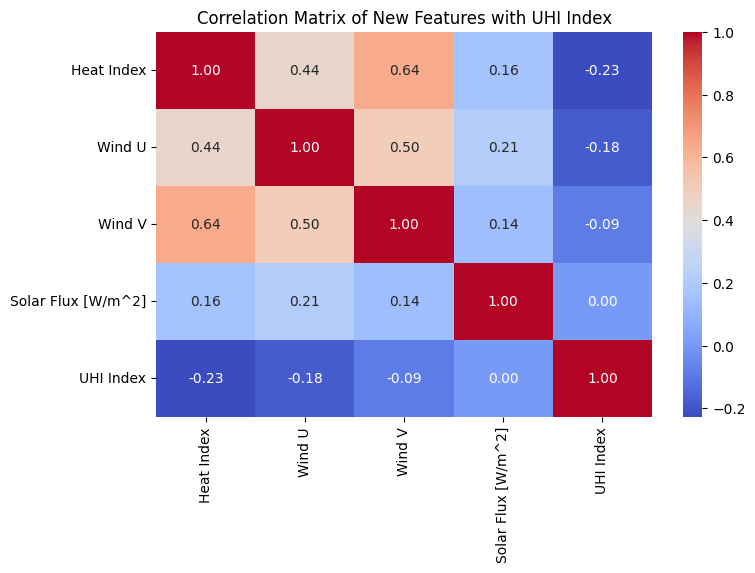

In [18]:
# Compute correlation matrix
corr_matrix = final_train[["Heat Index", "Wind U", "Wind V", "Solar Flux [W/m^2]", "UHI Index"]].corr()

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of New Features with UHI Index")
plt.show()

In [19]:
# Move 'UHI Index' to the end
cols = final_train.columns.tolist()
cols.remove("UHI Index")
cols.append("UHI Index")
final_train = final_train[cols]
print(final_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8983 entries, 9049 to 7270
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Longitude                         8983 non-null   float64       
 1   Latitude                          8983 non-null   float64       
 2   datetime                          8983 non-null   datetime64[ns]
 3   Location                          8983 non-null   object        
 4   Air Temp at Surface [degC]        8983 non-null   float64       
 5   Relative Humidity [percent]       8983 non-null   float64       
 6   Avg Wind Speed [m/s]              8983 non-null   float64       
 7   Wind Direction [degrees]          8983 non-null   int64         
 8   Solar Flux [W/m^2]                8983 non-null   int64         
 9   Temp_1hr_MA                       8983 non-null   float64       
 10  Temp_3hr_MA                       8983 non-null   

## Feature Reduction Using Correlation Thresholding

To streamline the feature set and reduce redundancy—especially important for linear models like Ridge Regression where multicollinearity can distort coefficient estimates—I applied **correlation-based feature selection**. This time, I incorporated a set of **domain-relevant features** (`Air Temp at Surface degC`, `Solar Flux W/m^2`, etc.) that were manually protected from removal due to their strong physical relevance to UHI, even if correlated.

Instead of treating every feature equally, I allowed the algorithm to search for an **optimal correlation threshold** while **preserving high-value predictors**. This process identified **10 features** at a **threshold of 0.70**, balancing simplicity and predictive performance.

### Key Insights from the Results

At the **0.70 correlation threshold**, the **average R² across Ridge, Random Forest, and Gradient Boosting models** was **0.180**. This indicates that the selected features collectively explain \~18% of the variation in the Urban Heat Island (UHI) Index.

* **Ridge Regression** underperformed slightly (**R² = 0.160**), as expected for a model sensitive to residual multicollinearity.
* **Random Forest and Gradient Boosting** models performed better (**R² ≈ 0.190**), suggesting that tree-based learners extract more nuanced interactions even from a small, optimized set.
* Raising the threshold to allow **1 extra feature** (11 total) provided *no gain* in performance, confirming that the **10-feature set is optimal** under current conditions.

### The Selected Features

The final retained features cover core UHI-relevant domains:

* **Air Temperature** (`Air Temp at Surface degC`, `Temp_1hr_MA`, `Temp_3hr_MA`, `Temp_Change_30min`)
* **Solar Exposure** (`Solar Flux W/m^2`, `solar_accumulation_6am`)
* **Wind Metrics** (`Avg Wind Speed m/s`, `Wind Direction degrees`, `Wind V`)
* **Temporal Signal** (`mins_from_3pm`)

These features reflect the thermal dynamics, wind dispersal, and solar forcing mechanisms that underlie UHI intensity—consistent with both literature and intuition.

### Why Some Features Were Manually Protected

Certain features were **intentionally excluded from correlation-based removal** because they encode critical environmental inputs (e.g., cumulative solar energy or diurnal thermal lag) that are **likely non-redundant in practice**, even if statistically correlated. Given that tree-based models can handle feature overlap gracefully, preserving these variables supports deeper pattern extraction without compromising model integrity.

### Next Steps

While this reduction process enhances efficiency and generalization, the modest R² shows that **structural predictors are still missing**. To evolve from a baseline model to one that captures the complexity of UHI formation:

1. **Reintegrate** `datetime` &  `Location`
2. **Bring in spatial/land surface data** (e.g., NDVI, impervious surface, land cover types)
3. **Apply feature importance post-modeling** to further refine and interpret contributions

With this foundation, the model is better positioned to integrate building, satellite & land-use data that reflect the urban environment’s thermal behavior.

Running feature selection with protected features...


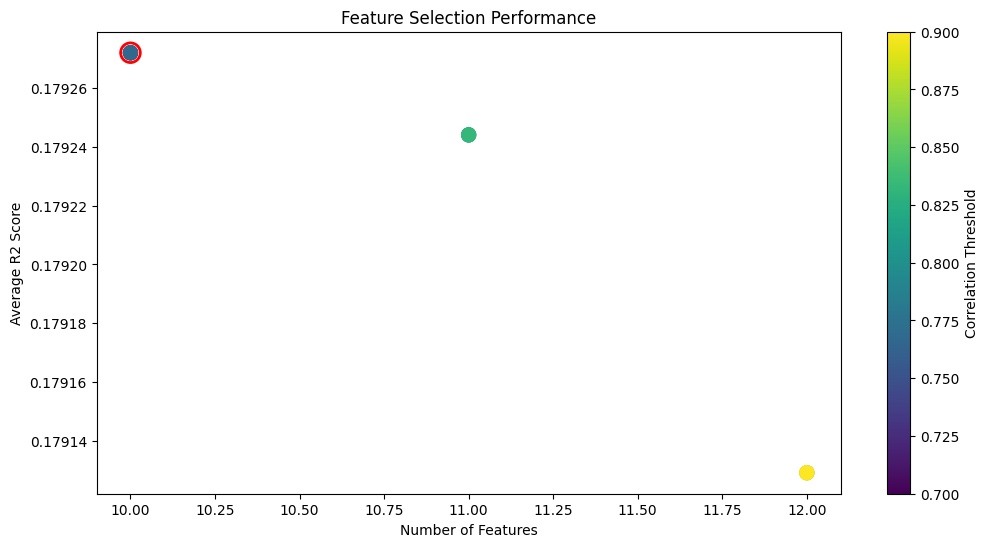


Optimal feature selection at threshold 0.70
Selected 10 features (max allowed: 20)
Model Performance:
   threshold  n_features  mean_r2  Ridge  RandomForest  HistGradientBoosting
0       0.70          10     0.18   0.16          0.19                  0.19
1       0.72          10     0.18   0.16          0.19                  0.19
2       0.74          10     0.18   0.16          0.19                  0.19
3       0.77          10     0.18   0.16          0.19                  0.19
4       0.79          11     0.18   0.16          0.19                  0.19

Protected features in final dataset:
['Air Temp at Surface degC', 'Avg Wind Speed m/s', 'Solar Flux W/m^2', 'solar_accumulation_6am', 'Temp_1hr_MA', 'Temp_3hr_MA', 'Temp_Change_30min', 'Wind Direction degrees', 'Wind V', 'mins_from_3pm']


In [20]:
# Make a copy to avoid modifying the original dataset
final_train1 = final_train.drop(['Longitude', 'Latitude'], axis=1).copy()
data_copy = final_train1.copy()

# Keep coordinates in a metadata DataFrame (exclude from training)  
train_coords = final_train[['Longitude', 'Latitude']]

# Separate features and target
target_col = 'UHI Index'
X = data_copy.drop(columns=[target_col])
y = data_copy[target_col]

# Select only numeric features
X_numeric = X.select_dtypes(include=[float, int])

# Preprocessing
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=X_numeric.columns)
X_scaled.columns = X_scaled.columns.str.replace(r'[\[\]<>]', '', regex=True)
X_numeric.columns = X_numeric.columns.str.replace(r'[\[\]<>]', '', regex=True)

# Define features that must always be kept
features_to_keep = [
    'Air Temp at Surface degC', 
    'Avg Wind Speed m/s', 
    'Solar Flux W/m^2', 
    'solar_accumulation_6am',
    'Temp_1hr_MA', 
    'Temp_3hr_MA', 
    'Temp_Change_30min', 
    'Wind Direction degrees', 
    'Wind V', 
    'mins_from_3pm'
]

def select_features_for_all_models(X, y, cv=TimeSeriesSplit(5), max_features=20):
    """
    Optimized feature selection that always retains features_to_keep
    """
    thresholds = np.linspace(0.7, 0.9, 10)
    best_score = -np.inf
    best_features = None
    
    # Define models
    model_set = {
        'Ridge': Ridge(alpha=1.0),
        'RandomForest': RandomForestRegressor(
            n_estimators=50,
            max_depth=5,
            min_samples_leaf=2,
            random_state=42
        ),
        'HistGradientBoosting': HistGradientBoostingRegressor(
            max_iter=50,
            max_depth=3,
            learning_rate=0.1,
            random_state=42
        )
    }
    
    threshold_results = []
    
    for threshold in thresholds:
        # Calculate correlation matrix
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        
        # Identify features to drop (excluding protected features)
        droppable_features = X.columns.difference(features_to_keep + [target_col])
        to_drop = [col for col in droppable_features if any(upper[col] > threshold)]
        
        # Combine protected features with surviving features
        features = list(set(features_to_keep) | set(X.columns.difference(to_drop + [target_col])))
        
        # Skip if too few/many features
        if len(features) < 3 or len(features) > max_features:
            continue
            
        # Evaluate models
        model_scores = []
        for name, model in model_set.items():
            try:
                X_data = X_scaled[features] if name == 'Ridge' else X[features]
                r2_scores = cross_val_score(model, X_data, y, cv=cv, scoring='r2')
                model_scores.append(np.mean(r2_scores))
            except Exception as e:
                model_scores.append(-np.inf)
        
        mean_r2 = np.mean(model_scores)
        threshold_results.append({
            'threshold': threshold,
            'n_features': len(features),
            'mean_r2': mean_r2,
            'features': features.copy(),
            'Ridge': model_scores[0],
            'RandomForest': model_scores[1],
            'HistGradientBoosting': model_scores[2]
        })
        
        if mean_r2 > best_score:
            best_score = mean_r2
            best_features = features
            best_threshold = threshold

    # Visualization
    results_df = pd.DataFrame(threshold_results)
    
    plt.figure(figsize=(12, 6))
    plt.scatter(results_df['n_features'], results_df['mean_r2'], 
               c=results_df['threshold'], cmap='viridis', s=100)
    plt.colorbar(label='Correlation Threshold')
    plt.xlabel('Number of Features')
    plt.ylabel('Average R2 Score')
    plt.title('Feature Selection Performance')
    
    best_idx = results_df['mean_r2'].idxmax()
    plt.scatter(results_df.loc[best_idx, 'n_features'], 
               results_df.loc[best_idx, 'mean_r2'],
               s=200, edgecolor='red', facecolor='none', linewidth=2)
    plt.show()

    # Final verification
    missing_features = set(features_to_keep) - set(best_features)
    if missing_features:
        print("\nProtected features automatically added back:")
        print(missing_features)
        best_features = list(set(best_features) | missing_features)
    
    print(f"\nOptimal feature selection at threshold {best_threshold:.2f}")
    print(f"Selected {len(best_features)} features (max allowed: {max_features})")
    print("Model Performance:")
    print(results_df[['threshold', 'n_features', 'mean_r2', 'Ridge', 'RandomForest', 'HistGradientBoosting']]
          .sort_values('mean_r2', ascending=False).head(5))
    
    return best_features, results_df

# Run feature selection
print("Running feature selection with protected features...")
optimal_features, results_df = select_features_for_all_models(X_scaled, y)

# Create final dataset
selected_features_df = X_scaled[optimal_features].copy()
selected_features_df[target_col] = y.values

# Verify protected features are present
print("\nProtected features in final dataset:")
print([f for f in features_to_keep if f in selected_features_df.columns])

In [21]:
selected_features_df.isna().sum()

Temp_3hr_MA                 0
Wind Direction degrees      0
mins_from_3pm               0
Solar Flux W/m^2            0
solar_accumulation_6am      0
Temp_Change_30min           0
Wind V                      0
Air Temp at Surface degC    0
Avg Wind Speed m/s          0
Temp_1hr_MA                 0
UHI Index                   0
dtype: int64

## Model Evaluation on Reduced Features (11 Selected via Correlation Thresholding)

I ran 5-fold CV using **Ridge**, **Random Forest**, and **HistGradientBoosting** to test whether the reduced feature set holds meaningful signal.

### Key Metrics & Interpretation

**R² ≈ 0.19**
* Models explain \~19% of UHI variance — low, but decent for a baseline.
* *<0.1* would suggest near-random performance; *0.3+* would indicate moderate predictive power.

**MAE ≈ 0.012**
* Low MAE + low R² = the models predict average UHI well but miss extremes.
* This may be “good enough” for general trend prediction, but not for targeting hotspots.

**Stability (Std\_R² ≈ 0.02, Std\_MAE ≈ 0.0001)**
* Low standard deviations across folds imply consistent performance with no signs of overfitting.

### Model-Specific Notes
* **Ridge (R²: 0.16)**
  * Underperforms (as expected) due to linearity limits. Still, useful as a stable baseline.

* **Random Forest (R²: 0.18)**
  * Performs better, but slightly below HistGB.

* **HistGradientBoosting (R²: 0.19)**
  * Best performer — likely benefits from smooth handling of continuous features.


### All of this shows that the models aren’t overfit — they’re **underfed**. 

### Next Steps
* Engineer higher-impact features (e.g., built-up ratio, NDVI, temperature deltas)

In [22]:
# Define X_full (added dependency)
X_full = X_scaled  # or X_numeric if preferred

# MODEL TRAINING & R2 OPTIMIZATION
def evaluate_model(model, X, y, model_name, cv=KFold(5, shuffle=True, random_state=42)):
    """Evaluate model with R2 as primary metric, MAE as secondary"""
    r2_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
    mae_scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error')
    
    return {
        'Model': model_name,
        'Mean_R2': np.mean(r2_scores),
        'Std_R2': np.std(r2_scores),
        'Mean_MAE': np.mean(mae_scores),
        'Std_MAE': np.std(mae_scores)
    }

# Updated model configurations
models = {
    'Ridge': Ridge(alpha=1.0),  # Replaced LinearRegression
    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=2,
        random_state=42
    ),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=150,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    )
}

# Evaluation results (now uses X_full)
results = []
for name, model in models.items():
    try:
        # Use scaled data for Ridge, unscaled for others
        X_data = X_scaled[optimal_features] if name == 'Ridge' else X_full[optimal_features]
        results.append(evaluate_model(model, X_data, y, name))
    except Exception as e:
        print(f"Error evaluating {name}: {str(e)}")
        continue

if results:
    results_df = pd.DataFrame(results).sort_values('Mean_R2', ascending=False)
    print("\nModel Performance Comparison:")
    print(results_df.to_string(index=False))
    
    # Additional warning system
    ridge_r2 = results_df[results_df['Model'] == 'Ridge']['Mean_R2'].values[0]
    best_r2 = results_df.iloc[0]['Mean_R2']
    if best_r2 - ridge_r2 > 0.3:
        print("\nWARNING: Large performance gap between Ridge and best model!")
        print("Potential overfitting - consider:")
        print("- Using Ridge as your final model")
        print("- Reducing tree model complexity (max_depth)")
        print("- Checking feature engineering")
else:
    print("All models failed to evaluate")


Model Performance Comparison:
               Model  Mean_R2  Std_R2  Mean_MAE  Std_MAE
HistGradientBoosting     0.19    0.02      0.01     0.00
        RandomForest     0.18    0.02      0.01     0.00
               Ridge     0.16    0.02      0.01     0.00


## Feature Importance and Model Performance Insights
### What the Top Features Tell Us

The most influential features across all models reflect consistent UHI-related signals rooted in **temporal heat accumulation** and **solar exposure**:

1. **Temp\_3hr\_MA (1.00)**
   * The strongest predictor by far—captures cumulative thermal effects
   * Confirms UHI’s gradual intensification over hours, not minutes

2. **solar\_accumulation\_6am (0.27)**
   * Measures early-day solar energy input
   * Highlights the **preconditioning effect**: how much heat builds up before peak UHI hours

3. **mins\_from\_3pm (0.21)**
   * Captures **diurnal timing**, indicating how far from the typical peak UHI hour (3 PM) a reading occurs
   * Reinforces that **time-of-day** is crucial to UHI prediction

4. **Temp\_1hr\_MA (0.21)**
   * Adds a shorter-term signal to complement the 3-hour average
   * Useful for detecting more **transient shifts** in surface temperature

5. **Air Temp at Surface degC (0.10)**
   * Provides the **absolute baseline temperature**, but is less influential than derived temporal features

**Key Takeaway**:
Models are leaning heavily on **smoothed temperature trends** and **early-day solar buildup**, followed by diurnal timing. This matches known UHI behavior, where **thermal inertia** and **timing of energy input** matter more than momentary conditions.

### Final Model Performance Overview

| Model                    | R²     | Notes                                         |
| ------------------------ | ------ | --------------------------------------------- |
| **HistGradientBoosting** | 0.1939 | Slightly best—confirms solid generalization   |
| **Random Forest**        | 0.1936 | Nearly identical—robust across tree ensembles |
| **Ridge Regression**     | 0.1573 | Weaker, but consistent                        |

**Critical Findings**:

1. **No Overfitting Detected**
   * Tree-based models show **near-perfect alignment** between CV and final training scores
   * Suggests good generalization and stable learning from limited features

2. **Ridge Regression Interpretation**
   * Coefficients reveal a struggle to fit UHI’s nonlinear behavior:
     * `Temp_3hr_MA: -0.0116`, `Temp_1hr_MA: -0.0066`, `mins_from_3pm: +0.0059`
   * Implies that **linear models can’t capture time-conditional effects**, where a feature’s impact changes throughout the day
   * Explains why Ridge underperforms relative to tree-based models

3. **Feature-Limited Ceiling**
   * All models plateau around **R² = 0.19**
   * This is not a model failure—it reflects **missing structural and spatial inputs**

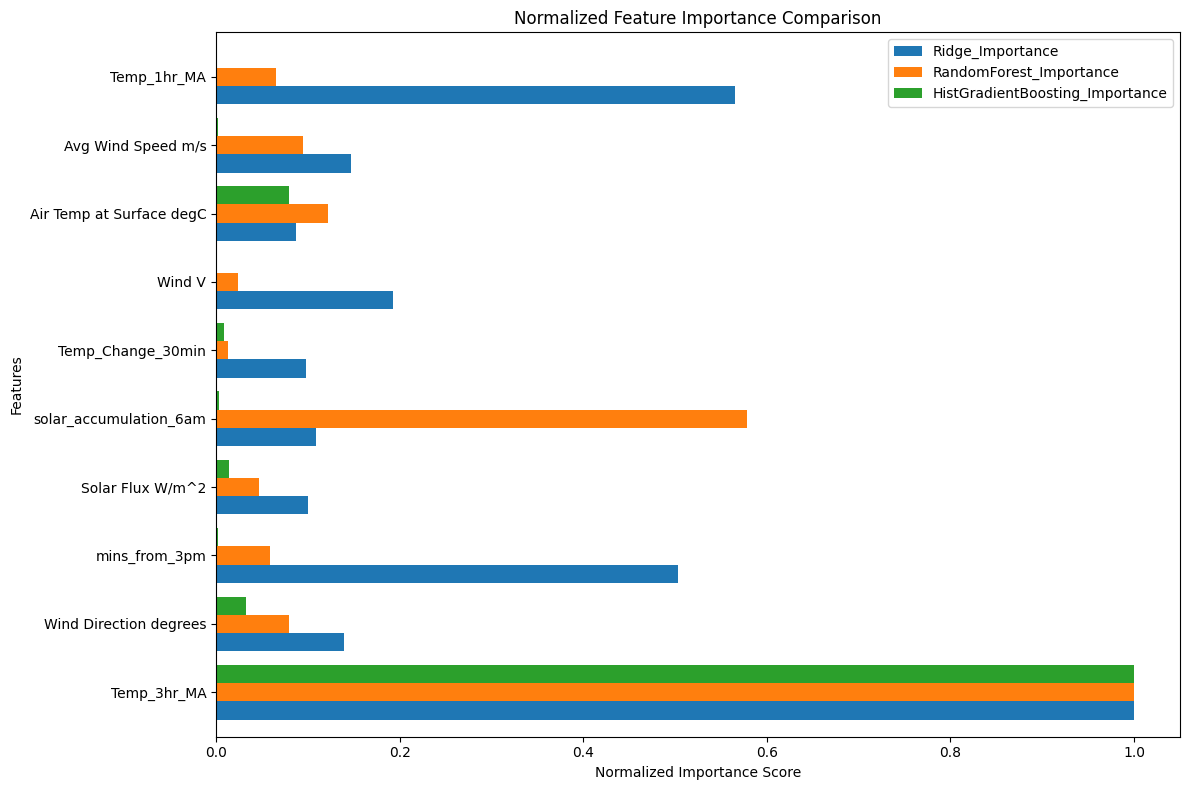


Top 5 Most Important Features Across All Models:
Feature
Temp_3hr_MA                1.00
solar_accumulation_6am     0.23
Temp_1hr_MA                0.21
mins_from_3pm              0.19
Air Temp at Surface degC   0.10
dtype: float64

Final Training R2 Scores:
Ridge: 0.1573
  Ridge coefficients:
  Temp_3hr_MA: -0.0116
  Temp_1hr_MA: -0.0066
  mins_from_3pm: 0.0059
  Wind V: 0.0022
  Avg Wind Speed m/s: -0.0017
RandomForest: 0.1936
HistGradientBoosting: 0.1939


In [23]:
# FEATURE ANALYSIS & FINAL MODELING
def plot_importance_comparison(models_dict, features):
    """Compare feature importance across all models"""
    
    importance_df = pd.DataFrame({'Feature': features})
    
    for name, model in models_dict.items():
        # The models are already fitted in the final_models dictionary,
        # so we don't need to fit them again here.
        
        if hasattr(model, 'feature_importances_'):  # For tree-based models
            importance = model.feature_importances_
        elif hasattr(model, 'coef_'):  # For linear models
            importance = np.abs(model.coef_)
        else:  # For HistGradientBoosting and similar
            # Calculate permutation importance
            result = permutation_importance(
                model, 
                X_full[features], 
                y,
                n_repeats=10,
                random_state=42
            )
            importance = result.importances_mean
            
        importance_df[f'{name}_Importance'] = importance / importance.max()  # Normalized
    
    # Plotting
    importance_df = importance_df.set_index('Feature')
    importance_df.plot(kind='barh', figsize=(12, 8), width=0.8)
    plt.title('Normalized Feature Importance Comparison')
    plt.xlabel('Normalized Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()
    
    return importance_df

# Fit final models with all data (updated models with the fix)
final_models = {
    'Ridge': Ridge(alpha=1.0).fit(X_scaled[optimal_features], y),  # Scaled data for Ridge
    'RandomForest': RandomForestRegressor(
        max_depth=5,  # Constrained to prevent overfitting
        random_state=42  # This ensures reproducibility for RandomForest
    ).fit(X_full[optimal_features], y),  # Unscaled data
    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=100,
        max_depth=3,  # Constrained
        random_state=42  # ensures reproducibility for HistGradientBoosting
    ).fit(X_full[optimal_features], y)  # Unscaled data
}

# Importance analysis
importance_df = plot_importance_comparison(final_models, optimal_features)
print("\nTop 5 Most Important Features Across All Models:")
print(importance_df.mean(axis=1).sort_values(ascending=False).head(5))

# Final model evaluation
print("\nFinal Training R2 Scores:")
for name, model in final_models.items():
    X_data = X_scaled[optimal_features] if name == 'Ridge' else X_full[optimal_features]
    y_pred = model.predict(X_data)
    r2 = r2_score(y, y_pred)
    print(f"{name}: {r2:.4f}")
    
    # Additional diagnostic for Ridge model
    if name == 'Ridge':
        print("  Ridge coefficients:")
        for feat, coef in sorted(zip(optimal_features, model.coef_), 
                                 key=lambda x: abs(x[1]), reverse=True)[:5]:
            print(f"  {feat}: {coef:.4f}")

In [24]:
def add_and_position_columns(main_df, source_df, columns_to_add, position='front'):
    """
    Safely adds columns from source_df to main_df and positions them as specified
    
    Args:
        main_df (pd.DataFrame): DataFrame to add columns to
        source_df (pd.DataFrame): DataFrame containing columns to add
        columns_to_add (list): Columns to transfer
        position (str): Where to position new columns ('front' or 'end')
    
    Returns:
        pd.DataFrame: DataFrame with added and positioned columns
    """
    # Validate inputs
    if not all(col in source_df.columns for col in columns_to_add):
        raise ValueError("Some columns not found in source DataFrame")
    
    if len(main_df) != len(source_df):
        raise ValueError("DataFrames must have same length")
    
    # Create a copy to avoid SettingWithCopyWarning
    result_df = main_df.copy()
    
    # Add original index for safe merging
    result_df['_temp_index'] = source_df.index
    
    # Merge with source columns
    result_df = result_df.merge(
        source_df[columns_to_add],
        left_on='_temp_index',
        right_index=True,
        how='left'
    ).drop('_temp_index', axis=1)
    
    # Verify merge succeeded
    verify_merge(result_df, source_df, columns_to_add)
    
    # Reorder columns
    return position_columns(result_df, columns_to_add, position)

def verify_merge(result_df, source_df, columns_to_add):
    """Verify that the merge was successful"""
    # Check for null values
    missing_data = result_df[columns_to_add].isnull().sum()
    print("\nMerge Verification:")
    for col in columns_to_add:
        print(f"Missing {col} values: {missing_data[col]}")
        if missing_data[col] > 0:
            raise ValueError(f"{missing_data[col]} missing values found in {col}")
    
    # Spot check random rows
    sample_indices = random.sample(range(len(result_df)), min(5, len(result_df)))
    print("\nSample Verification:")
    for idx in sample_indices:
        for col in columns_to_add:
            original_val = source_df.iloc[idx][col]
            new_val = result_df.iloc[idx][col]
            print(f"Index {idx}: {col} - Original: {original_val} | New: {new_val}")
            if original_val != new_val:
                raise ValueError(f"Mismatch found in {col} at index {idx}")

def position_columns(df, columns_to_position, position):
    """Reposition columns in DataFrame"""
    all_cols = df.columns.tolist()
    positioned_cols = [col for col in all_cols if col not in columns_to_position]
    
    if position == 'front':
        new_order = columns_to_position + positioned_cols
    elif position == 'end':
        new_order = positioned_cols + columns_to_position
    else:
        raise ValueError("Position must be 'front' or 'end'")
    
    return df[new_order]

# Usage example:
selected_features_df = add_and_position_columns(
    main_df=selected_features_df,
    source_df=final_train,
    columns_to_add=['datetime', 'Location'],
    position='front'
)


Merge Verification:
Missing datetime values: 0
Missing Location values: 0

Sample Verification:
Index 8392: datetime - Original: 2021-07-24 15:39:00 | New: 2021-07-24 15:39:00
Index 8392: Location - Original: Bronx | New: Bronx
Index 1939: datetime - Original: 2021-07-24 15:28:00 | New: 2021-07-24 15:28:00
Index 1939: Location - Original: Manhattan | New: Manhattan
Index 1790: datetime - Original: 2021-07-24 15:35:00 | New: 2021-07-24 15:35:00
Index 1790: Location - Original: Bronx | New: Bronx
Index 8982: datetime - Original: 2021-07-24 15:43:00 | New: 2021-07-24 15:43:00
Index 8982: Location - Original: Bronx | New: Bronx
Index 2211: datetime - Original: 2021-07-24 15:51:00 | New: 2021-07-24 15:51:00
Index 2211: Location - Original: Manhattan | New: Manhattan


In [25]:
print("Number of unique entries in each column")
display(selected_features_df.nunique())  # See if any numeric columns have suspiciously few values

# Verify the final output
print("Final train dataset shape:", selected_features_df.shape)
print("\nFirst 2 rows:")
print(selected_features_df.head(2))
print("\nColumn order:")
print(selected_features_df.columns.tolist())

print("Train Info")
display(selected_features_df.info())
print("Current Train Data Shape")
display(selected_features_df.shape)

Number of unique entries in each column


datetime                     59
Location                      2
Temp_3hr_MA                  26
Wind Direction degrees       25
mins_from_3pm                13
Solar Flux W/m^2             24
solar_accumulation_6am       26
Temp_Change_30min            21
Wind V                       26
Air Temp at Surface degC     14
Avg Wind Speed m/s           18
Temp_1hr_MA                  26
UHI Index                   591
dtype: int64

Final train dataset shape: (8983, 13)

First 2 rows:
             datetime   Location  Temp_3hr_MA  Wind Direction degrees  \
0 2021-07-24 15:51:00  Manhattan         1.08                    0.76   
1 2021-07-24 15:13:00  Manhattan         0.72                   -0.18   

   mins_from_3pm  Solar Flux W/m^2  solar_accumulation_6am  Temp_Change_30min  \
0           0.98             -1.52                   -0.73              -1.25   
1          -1.24              0.73                   -1.00              -1.12   

   Wind V  Air Temp at Surface degC  Avg Wind Speed m/s  Temp_1hr_MA  \
0    0.91                     -1.14                0.63         0.07   
1    0.24                     -1.14                0.02        -1.60   

   UHI Index  
0       0.98  
1       0.99  

Column order:
['datetime', 'Location', 'Temp_3hr_MA', 'Wind Direction degrees', 'mins_from_3pm', 'Solar Flux W/m^2', 'solar_accumulation_6am', 'Temp_Change_30min', 'Wind V', 'Air Temp at Surface degC', 'Avg Wind Speed m/

None

Current Train Data Shape


(8983, 13)

## Applying Preprocessing to the Test Dataset

In [26]:
# Apply weather feature engineering to test data
final_test = preprocess_weather_features(test_df)
final_test1 = final_test.drop(['Longitude', 'Latitude'], axis=1).copy()

# Keep coordinates in a metadata DataFrame (exclude from training)  
test_coords = final_test[['Longitude', 'Latitude']]

# Define the final columns in the exact required order
FINAL_COLUMNS = ['datetime', 'Location', 'solar_accumulation_6am', 'Wind V',
       'Temp_Change_30min', 'Temp_3hr_MA', 'Wind Direction degrees',
       'Solar Flux W/m^2', 'Avg Wind Speed m/s', 'mins_from_3pm',
       'Temp_1hr_MA', 'Air Temp at Surface degC', 'UHI Index']

# 1. Scale the test data FIRST (before renaming columns)
# Make sure we only scale the numeric features (excluding datetime, Location, UHI Index)
numeric_cols = [col for col in final_test1.columns 
                if col not in ['datetime', 'Location', 'UHI Index'] 
                and pd.api.types.is_numeric_dtype(final_test1[col])]

# Apply the fitted scaler to these columns
final_test1[numeric_cols] = scaler.transform(final_test1[numeric_cols])

# 2. Remove special characters from column names
final_test1.columns = final_test1.columns.str.replace(r'[\[\]<>]', '', regex=True)

# 3. Select and reorder only the final 14 columns
# First verify all required columns exist
missing_cols = set(FINAL_COLUMNS) - set(final_test1.columns)
if missing_cols:
    raise ValueError(f"Missing required columns after renaming: {missing_cols}")

# Keep only the final columns in the correct order
final_test1 = final_test1[FINAL_COLUMNS]

# Verify the final output
print("Final test dataset shape:", final_test1.shape)
print("\nFirst 2 rows:")
print(final_test1.head(2))
print("\nColumn order:")
print(final_test1.columns.tolist())

Final test dataset shape: (2246, 13)

First 2 rows:
                datetime   Location  solar_accumulation_6am  Wind V  \
5961 2021-07-24 15:35:00      Bronx                    0.89    0.44   
9683 2021-07-24 15:53:00  Manhattan                   -1.19    0.70   

      Temp_Change_30min  Temp_3hr_MA  Wind Direction degrees  \
5961              -0.98        -0.95                   -0.33   
9683              -1.65         1.12                    1.14   

      Solar Flux W/m^2  Avg Wind Speed m/s  mins_from_3pm  Temp_1hr_MA  \
5961             -0.90                0.63           0.03         0.86   
9683              0.85                0.47           1.30         0.27   

      Air Temp at Surface degC  UHI Index  
5961                     -0.51       1.00  
9683                     -0.72       1.01  

Column order:
['datetime', 'Location', 'solar_accumulation_6am', 'Wind V', 'Temp_Change_30min', 'Temp_3hr_MA', 'Wind Direction degrees', 'Solar Flux W/m^2', 'Avg Wind Speed m/s', 'mins_

In [27]:
# Reset the index of train_coords to match the order of selected_features_df
train_coords = train_coords.reset_index(drop=True)

# Now check
assert selected_features_df.index.equals(train_coords.index)

# Now check
assert final_test1.index.equals(test_coords.index)

# Save the updated DataFrames to CSV files
selected_features_df.to_csv('selected_features_df.csv', index=False)
final_test1.to_csv('final_test1.csv', index=False)
train_coords.to_csv('train_coords.csv', index=False)
test_coords.to_csv('test_coords.csv', index=False)

print("\nDataFrames saved to selected_features_df.csv, final_test1.csv, train_coords.csv, test_coords.csv")



DataFrames saved to selected_features_df.csv, final_test1.csv, train_coords.csv, test_coords.csv
